In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Auto-detect if running on Kaggle or locally
KAGGLE_PATH = Path('/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1')
LOCAL_PATH = Path('./')  # Local folder

DATA_DIR = KAGGLE_PATH if KAGGLE_PATH.exists() else LOCAL_PATH
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

<h5> Criteria 1 -> Dtypes of different Columns </h5>

In [2]:
print(train_df.dtypes)

id               int64
airline            str
flight             str
source             str
departure          str
stops              str
arrival            str
destination        str
class              str
duration       float64
days_left      float64
price            int64
dtype: object


<h5>Criteria 2 -> Descriptive Stats of Numerical Columns </h5> 

In [3]:
print(train_df.describe()) # descriptive stats of id are not useful. describe() method by default gives stats for numeric cols.

                id      duration     days_left         price
count  40000.00000  36987.000000  35562.000000   40000.00000
mean   19999.50000     12.004088     26.197936   20801.49025
std    11547.14972      7.108063     13.469232   22729.14842
min        0.00000      0.830000      1.000000    1105.00000
25%     9999.75000      6.670000     15.000000    4687.00000
50%    19999.50000     11.080000     26.000000    7353.00000
75%    29999.25000     15.920000     38.000000   42521.00000
max    39999.00000     47.080000     49.000000  114704.00000


<h4>Criteria 3 Starts</h4>

<h5>Before running model on test.csv directly we will be breaking down train.csv into training set and validation set.</h5>

In [4]:
X = train_df.drop(columns=['id', 'flight', 'price']) # dropping id, flight and price column id is not useful. flight column will make training complex, price column will be used for validation set
y = train_df['price']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

<h5>Visualizations</h5>

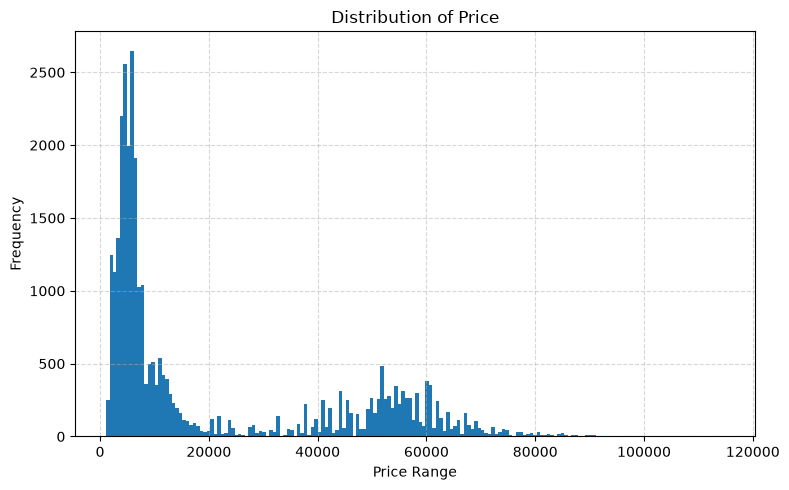

In [5]:
# Plotting histogram of y_train which is price column

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(y_train, bins=178)
ax.set_title('Distribution of Price')
ax.set_xlabel('Price Range')
ax.set_ylabel('Frequency')
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()

plt.show()

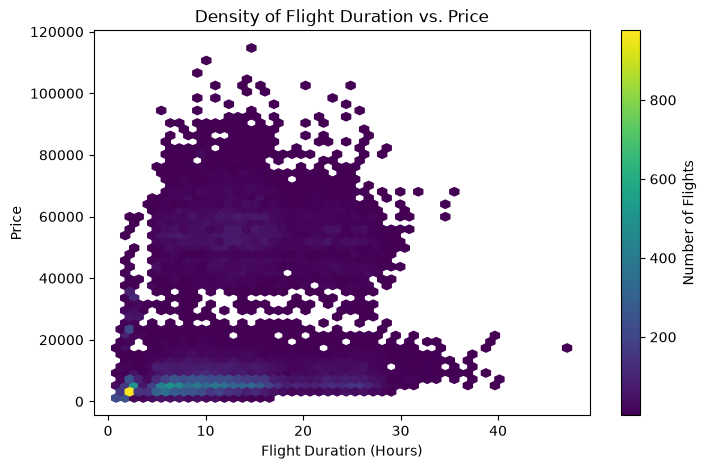

In [6]:
# Plotting hexbin for duration v/s price

plt.figure(figsize=(8, 5))
plt.hexbin(X_train['duration'], y_train, gridsize=50, cmap='viridis', mincnt=1)
plt.colorbar(label='Number of Flights')
plt.xlabel('Flight Duration (Hours)')
plt.ylabel('Price')
plt.title('Density of Flight Duration vs. Price')
plt.show()

/tmp/ipykernel_66777/1799609264.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_train, x='class', y=y_train, palette='Set2')


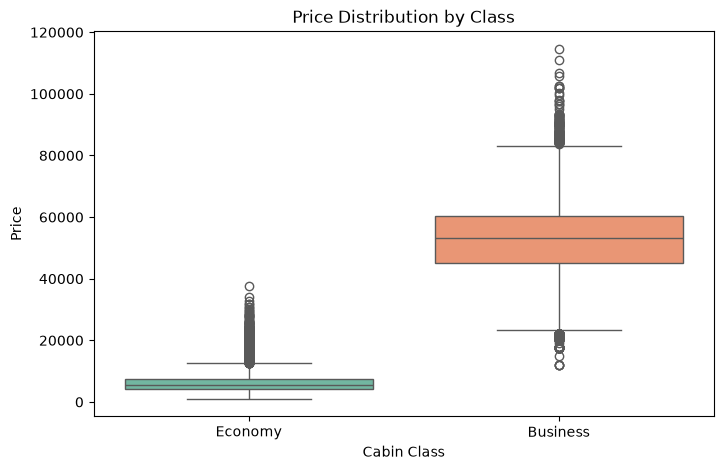

In [7]:
# boxplot for class v/s price to check for outliers

plt.figure(figsize=(8, 5))
sns.boxplot(data=X_train, x='class', y=y_train, palette='Set2')
plt.xlabel('Cabin Class')
plt.ylabel('Price')
plt.title('Price Distribution by Class')
plt.show()

<h5>Data-Preprocessing Part</h5>

In [8]:
print(X_train.isna().sum())

# Below prints are all for Categorical data which we will encode. Using unique to find unique values to encode

print(X_train['airline'].unique())
print(X_train['source'].unique())
print(X_train['departure'].unique())
print(X_train['stops'].unique())
print(X_train['arrival'].unique())
print(X_train['destination'].unique())
print(X_train['class'].unique())

# For numerical data which is duration and days_left we have nan values we will fill them directly.

airline        3727
source            0
departure      3827
stops          1845
arrival           0
destination       0
class             0
duration       2430
days_left      3554
dtype: int64
<StringArray>
['GO_FIRST', 'Vistara', 'Indigo', nan, 'Air_India', 'AirAsia', 'SpiceJet']
Length: 7, dtype: str
<StringArray>
['Delhi', 'Hyderabad', 'Kolkata', 'Mumbai', 'Bangalore', 'Chennai']
Length: 6, dtype: str
<StringArray>
['Evening', 'Morning', 'Afternoon', 'Early_Morning', 'Night', nan,
 'Late_Night']
Length: 7, dtype: str
<StringArray>
['one', 'zero', 'two_or_more', nan]
Length: 4, dtype: str
<StringArray>
['Night', 'Evening', 'Afternoon', 'Morning', 'Early_Morning', 'Late_Night']
Length: 6, dtype: str
<StringArray>
['Bangalore', 'Kolkata', 'Chennai', 'Delhi', 'Hyderabad', 'Mumbai']
Length: 6, dtype: str
<StringArray>
['Economy', 'Business']
Length: 2, dtype: str


In [9]:
# Columns have been seperated out to apply ColumnTransformer later

numeric_cols = ['duration', 'days_left']
categorical_cols_ohe = ['airline', 'source', 'departure', 'arrival', 'destination', 'class']
categorical_cols_ord = ['stops']

# Building Pipeline because we will impute and encode at once.
# ohe -> OneHotEncoder, ord -> OrdinalEncoder

numeric_si = SimpleImputer(strategy='median')
categorical_si = SimpleImputer(strategy='most_frequent')

categorical_encoding_ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

stops_order = [['zero', 'one', 'two_or_more']] # We need to do this so that OrdinalEncoder doesnt do encoding alphabetically, which is its default settings. Encoding will be 0, 1, 2
categorical_encoding_ord = OrdinalEncoder(categories=stops_order) # Using this for 'stops' column 


# Building Pipelines

categorical_pipeline_ohe = Pipeline(steps=[('imputer', categorical_si),
                                           ('encode', categorical_encoding_ohe)])

categorical_pipeline_ord = Pipeline(steps=[('imputer', categorical_si),
                                           ('encode', categorical_encoding_ord)])

numeric_pipeline = Pipeline(steps=[('imputer', numeric_si),
                                   ('standardize', StandardScaler())])


# Applying ColumnTransformer

col_preprocessor = ColumnTransformer(transformers=[('numeric', numeric_pipeline, numeric_cols),
                                                   ('cat_ohe', categorical_pipeline_ohe, categorical_cols_ohe),
                                                   ('cat_ord', categorical_pipeline_ord, categorical_cols_ord)],
                                    remainder='drop')


X_train_prep = col_preprocessor.fit_transform(X_train) 
X_val_prep = col_preprocessor.transform(X_val)

<h5>Applying Machine Learning Models Now</h5>

<h5>Dummy Regression</h5>

In [10]:
# Dummy Regressor model for baseline Metrics

dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train_prep, y_train)

y_pred_dummy = dummy_model.predict(X_val_prep)
mse_dummy = mean_squared_error(y_val, y_pred_dummy)
mae_dummy = mean_absolute_error(y_val, y_pred_dummy)
r2_dummy = r2_score(y_val, y_pred_dummy)

print("Dummey Regressor Metrics\n")
print(f"MSE: {mse_dummy:.4f}")
print(f"MAE: {mae_dummy:.4f}")
print(f"R2_Score: {r2_dummy:.4f}")

Dummey Regressor Metrics

MSE: 515963033.8245
MAE: 19766.4230
R2_Score: -0.0000


<h5>Linear Regression - Normal, Ridge and Lasso</h5>

In [11]:
# Implementing Linear Regression (Normal)

linear_model = LinearRegression()
linear_model.fit(X_train_prep, y_train)

y_pred_linear = linear_model.predict(X_val_prep)
mse_linear = mean_squared_error(y_val, y_pred_linear)
mae_linear = mean_absolute_error(y_val, y_pred_linear)
r2_linear = r2_score(y_val, y_pred_linear)

print("Linear Regression Metrics\n")
print(f"MSE: {mse_linear:.4f}")
print(f"MAE: {mae_linear:.4f}")
print(f"R2_Score: {r2_linear:.4f}")

Linear Regression Metrics

MSE: 48196077.7579
MAE: 4602.8425
R2_Score: 0.9066


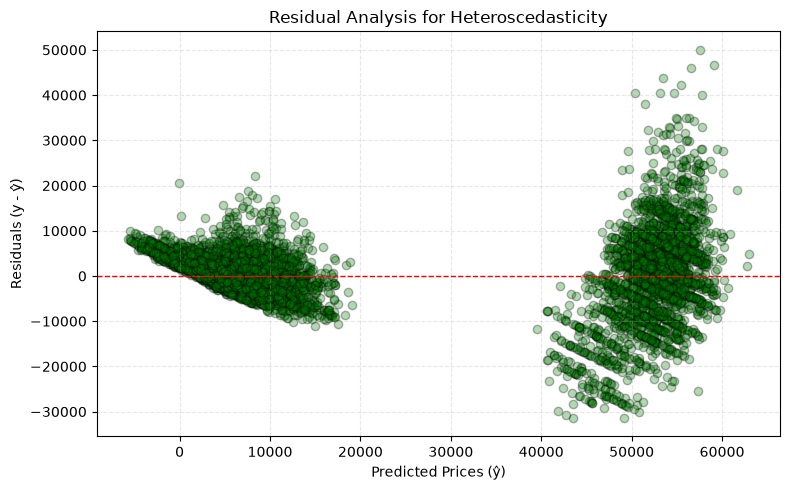

In [12]:
# In visualizations we saw that y_train, which is price column, has bimodal distribution and not Normal distribution we will be plotting residuals which is (y_val - y_pred_linear) and we will be able to see that how big prices of business class are affecting Linear Regression.

# The intution to plot residuals is that MAE for Linear Regression is 4,602 whereas from boxplot visulaization the median of business class sits at 55,000 when we take abs difference it is going to be very high. Also bimodal distribution of price column gives us intution to check for residuals.

# Residual analsyis will also tell us about heteroscedasticity of data because linear model assumes Homoscedasticty of Data.

residuals = y_val - y_pred_linear

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_linear, residuals, alpha=0.3, edgecolors='k', color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Prices (ŷ)")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residual Analysis for Heteroscedasticity")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# The above scatter plot confirms the presence of Heteroscedasticity in Price column because the variance of right cluster moves from -30,000 to +50,000 whereas variance of left cluster is relativelty stable moving form -10,000 to +20,000. This spread of variance was also confirmed in Boxplot Visulaiztion.

# To tackle problem of Heteroscedasticity here we will be using natural log of y_train now, which is natural log of Price Column 

y_train_log = np.log1p(y_train) # Using log1p for precision
y_val_log = np.log1p(y_val)

# Applying linear Regression again

linear_model.fit(X_train_prep, y_train_log)
y_pred_log = linear_model.predict(X_val_prep) # This will give output in log-space so we need to inverse the outputs to bring them back to orginal dataset space which is rupees

y_pred_inverse = np.expm1(y_pred_log) # Getting back to real dataset space

mse_linear_log = mean_squared_error(y_val, y_pred_inverse)
mae_linear_log = mean_absolute_error(y_val, y_pred_inverse)
r2_linear_log = r2_score(y_val, y_pred_inverse)

print("Linear Regression Metrics with y_train transfromed to log(y_train)\n")
print(f"MSE: {mse_linear_log:.4f}")
print(f"MAE: {mae_linear_log:.4f}")
print(f"R2_Score: {r2_linear_log:.4f}")


Linear Regression Metrics with y_train transfromed to log(y_train)

MSE: 59578222.0639
MAE: 4584.3204
R2_Score: 0.8845


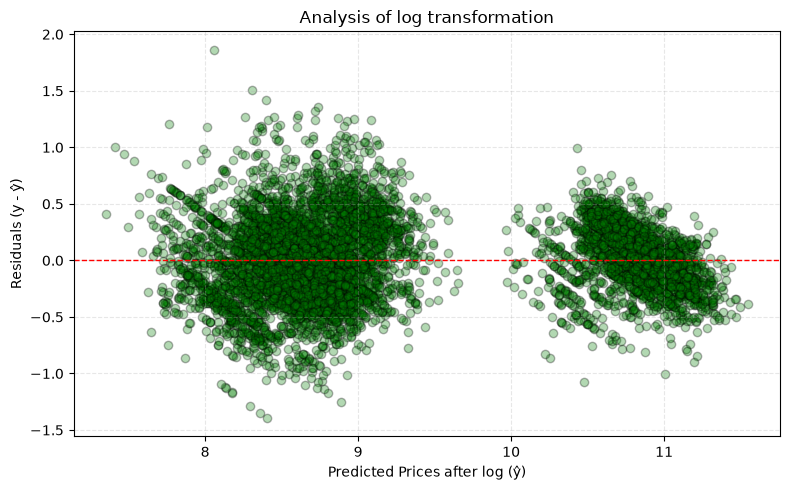

In [14]:
# Plotting residuals again 

residuals_2 = y_val_log - y_pred_log

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_log, residuals_2, alpha=0.3, edgecolors='k', color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Prices after log (ŷ)")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Analysis of log transformation")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# The variance of both classes Economy and Business class lie b/w -1.0 to +1.0 which has removed the problem of Heteroscedasticity. Though R2_score is less than original Linear Regression but MAE has decreased for log tranformed model and we have also removed the issue of heteroscedasticity. So overall log transformed model will perform much better on test_df than original Linear Regression model. 


In [15]:
# Implementing Ridge Regression

# Using RidgeCV to get best value of alpha and using log transformed y_train and y_val for this

alphas = alphas = np.logspace(-3, 3, 100)
ridge_cv_log_model = RidgeCV(alphas=alphas,
                             cv=5,
                             scoring='neg_mean_squared_error')

ridge_cv_log_model.fit(X_train_prep, y_train_log)

best_alpha_linear = ridge_cv_log_model.alpha_
print(f"Best alpha is: {best_alpha_linear}\n")

y_pred_log_ridge = ridge_cv_log_model.predict(X_val_prep)
y_pred_inverse_ridge = np.expm1(y_pred_log_ridge)

mse_ridge_log = mean_squared_error(y_val, y_pred_inverse_ridge)
mae_ridge_log = mean_absolute_error(y_val, y_pred_inverse_ridge)
r2_ridge_log = r2_score(y_val, y_pred_inverse_ridge)

print("RidgeCV Regression Metrics (Log Transformed y_train)\n")
print(f"MSE: {mse_ridge_log:.4f}")
print(f"MAE: {mae_ridge_log:.4f}")
print(f"R2_Score: {r2_ridge_log:.4f}")

Best alpha is: 10.0

RidgeCV Regression Metrics (Log Transformed y_train)

MSE: 59544650.8255
MAE: 4583.4801
R2_Score: 0.8846


In [16]:
# Implementing Lasso Regression

# Using LassoCV and we will be still using log transformed price

lasso_cv_log_model = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso_cv_log_model.fit(X_train_prep, y_train_log)

print(f"alpha chosen by LassoCV is: {lasso_cv_log_model.alpha_:.4f}\n")

y_pred_log_lasso = lasso_cv_log_model.predict(X_val_prep)
y_pred_inverse_lasso = np.expm1(y_pred_log_lasso)

mse_lasso_log = mean_squared_error(y_val, y_pred_inverse_lasso)
mae_lasso_log = mean_absolute_error(y_val, y_pred_inverse_lasso)
r2_lasso_log = r2_score(y_val, y_pred_inverse_lasso)

print("LassoCV Regression Metrics (Log Transformed y_train)\n")
print(f"MSE: {mse_lasso_log:.4f}")
print(f"MAE: {mae_lasso_log:.4f}")
print(f"R2_Score: {r2_lasso_log:.4f}")

alpha chosen by LassoCV is: 0.0005

LassoCV Regression Metrics (Log Transformed y_train)

MSE: 59320343.6787
MAE: 4577.6765
R2_Score: 0.8850


<h5>We see that all Linear Models - Original, Ridge and Lasso give almost same identical R2_Score. Now we will be moving to more complex models to get a better model.</h5>

<h5>Polynomial Regression</h5>

In [17]:
# Implmenting Polynomial Regression 

# This code takes somewhere between 2-3mins to fully run. Thats why its commented, to check results run this cell and wait for 2-3mins.

'''
poly_transformer = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly_transformer.fit_transform(X_train_prep)
X_val_poly = poly_transformer.transform(X_val_prep)

print(f"Shape of original Feature space X_train_prep: {X_train_prep.shape}")
print(f"Shape of transformed Feature space X_train_poly: {X_train_poly.shape}")

# Because Polynomial Features transformation will take out number of columns from 35 to 665 we will be using Ridge Regression to tackle the problem of Multicollinearity.

alphas = np.logspace(-3, 3, 100)
poly_ridge_model = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')

# We will be still using log transformed y_train

poly_ridge_model.fit(X_train_poly, y_train_log)
best_alpha_poly = poly_ridge_model.alpha_

print(f"Best alpha chosen is: {best_alpha_poly}\n")

y_pred_log_poly = poly_ridge_model.predict(X_val_poly)
y_pred_inverse_poly = np.expm1(y_pred_log_poly)

mse_poly = mean_squared_error(y_val, y_pred_inverse_poly)
mae_poly = mean_absolute_error(y_val, y_pred_inverse_poly)
r2_poly = r2_score(y_val, y_pred_inverse_poly)


print("Polynomial Regression Metrics (Log Transformed y_train)\n")
print(f"MSE: {mse_poly:.4f}")
print(f"MAE: {mae_poly:.4f}")
print(f"R2_Score: {r2_poly:.4f}")
'''

# RidgeCV takes 2.5mins to solve this we will be using SGDRegressor with penalty L2 to cut down on computing time. 


'\npoly_transformer = PolynomialFeatures(degree=2, include_bias=False)\n\nX_train_poly = poly_transformer.fit_transform(X_train_prep)\nX_val_poly = poly_transformer.transform(X_val_prep)\n\nprint(f"Shape of original Feature space X_train_prep: {X_train_prep.shape}")\nprint(f"Shape of transformed Feature space X_train_poly: {X_train_poly.shape}")\n\n# Because Polynomial Features transformation will take out number of columns from 35 to 665 we will be using Ridge Regression to tackle the problem of Multicollinearity.\n\nalphas = np.logspace(-3, 3, 100)\npoly_ridge_model = RidgeCV(alphas=alphas, cv=5, scoring=\'neg_mean_squared_error\')\n\n# We will be still using log transformed y_train\n\npoly_ridge_model.fit(X_train_poly, y_train_log)\nbest_alpha_poly = poly_ridge_model.alpha_\n\nprint(f"Best alpha chosen is: {best_alpha_poly}\n")\n\ny_pred_log_poly = poly_ridge_model.predict(X_val_poly)\ny_pred_inverse_poly = np.expm1(y_pred_log_poly)\n\nmse_poly = mean_squared_error(y_val, y_pred_inv

In [18]:
# Using SGDRegressor to solve with PolynomialFeatures

poly_tranformer = PolynomialFeatures(degree=2, interaction_only=True)

X_train_poly = poly_tranformer.fit_transform(X_train_prep)
X_val_poly = poly_tranformer.transform(X_val_prep)

sgd_reg = SGDRegressor(loss='squared_error', penalty='l2', alpha=0.0001, max_iter=1000, random_state=42)

sgd_reg.fit(X_train_poly, y_train_log)

y_pred_log_poly = sgd_reg.predict(X_val_poly)

y_pred_inverse_poly = np.expm1(y_pred_log_poly)

mse_poly = mean_squared_error(y_val, y_pred_inverse_poly)
mae_poly = mean_absolute_error(y_val, y_pred_inverse_poly)
r2_poly = r2_score(y_val, y_pred_inverse_poly)


print("Polynomial Regression Metrics (Log Transformed y_train)\n")
print(f"MSE: {mse_poly:.4f}")
print(f"MAE: {mae_poly:.4f}")
print(f"R2_Score: {r2_poly:.4f}")

Polynomial Regression Metrics (Log Transformed y_train)

MSE: 32772283.9591
MAE: 3388.9979
R2_Score: 0.9365


<h5>Decision Tree Model</h5>

In [19]:
tree_model = DecisionTreeRegressor(random_state=42)

# Still we will be using log transformed y_train 

tree_model.fit(X_train_prep, y_train_log)

y_pred_log_tree = tree_model.predict(X_val_prep)
y_pred_inverse_tree = np.expm1(y_pred_log_tree)

mse_tree = mean_squared_error(y_val, y_pred_inverse_tree)
mae_tree = mean_absolute_error(y_val, y_pred_inverse_tree)
r2_tree = r2_score(y_val, y_pred_inverse_tree)

print("Decision Tree Regression Metrics (Log Transformed y_train)\n")
print(f"MSE: {mse_tree:.4f}")
print(f"MAE: {mae_tree:.4f}")
print(f"R2_Score: {r2_tree:.4f}")

Decision Tree Regression Metrics (Log Transformed y_train)

MSE: 26700286.0915
MAE: 2416.0246
R2_Score: 0.9483


<h5>Hyperparameter tuning of Decision Tree</h5>

In [20]:
parameter_grid_dt = {'max_depth':[15,20,25,30,35,50,70,None],
                  'min_samples_leaf':[1,2,5,10,15,20,30,40],
                  'min_samples_split':[2,5,10,12,15]}

grid_search_dt = GridSearchCV(DecisionTreeRegressor(random_state=42),
                           param_grid=parameter_grid_dt,
                           cv=3,
                           scoring='r2',
                           n_jobs=-1)

grid_search_dt.fit(X_train_prep, y_train_log)
print(f"Best Parameters: {grid_search_dt.best_params_}")
print(f"Best CV R2_Score: {grid_search_dt.best_score_:.4f}")

Best Parameters: {'max_depth': 30, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best CV R2_Score: 0.9454


In [21]:
# Using best parameters obtained from above cell 

best_dt = grid_search_dt.best_estimator_

y_pred_log_best_dt = best_dt.predict(X_val_prep)
y_pred_inverse_best_dt = np.expm1(y_pred_log_best_dt)

mse_best_dt = mean_squared_error(y_val, y_pred_inverse_best_dt)
mae_best_dt = mean_absolute_error(y_val, y_pred_inverse_best_dt)
r2_best_dt = r2_score(y_val, y_pred_inverse_best_dt)

print("Tuned Decision Tree Metrics (Validation Set)\n")
print(f"MSE: {mse_best_dt:.4f}")
print(f"MAE: {mae_best_dt:.4f}")
print(f"R2_Score: {r2_best_dt:.4f}")

Tuned Decision Tree Metrics (Validation Set)

MSE: 21107873.3769
MAE: 2559.4192
R2_Score: 0.9591


<h5>Random Forest Regression</h5>

In [22]:
# Using Ensemble Method now which is RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=30, min_samples_leaf=5, random_state=42, n_jobs=-1)

# Using log transformed y_train

rf_model.fit(X_train_prep, y_train_log)

y_pred_log_rf = rf_model.predict(X_val_prep)
y_pred_inverse_rf = np.expm1(y_pred_log_rf)

mse_rf = mean_squared_error(y_val, y_pred_inverse_rf)
mae_rf = mean_absolute_error(y_val, y_pred_inverse_rf)
r2_rf = r2_score(y_val, y_pred_inverse_rf)

print("Random Forest Regressor Metrics (Log Transformed y_train)\n")
print(f"MSE: {mse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R2_Score: {r2_rf:.4f}")

Random Forest Regressor Metrics (Log Transformed y_train)

MSE: 17005505.9052
MAE: 2211.6757
R2_Score: 0.9670


<h5>Hyperparameter tuning of Random Forest Regressor</h5>

In [23]:
# The code of this cell takes time between 3-4mins to run completly, thats why commenting it. If you want to see the best parameters and best R2_Score you can run this but please be patient and wait for few minutes, ignore the 'sklearn.utils.parallel.delayed' warning.


parameter_grid_rf = {"n_estimators":[150,200,300],
                     "max_depth":[30, None],
                     "min_samples_leaf":[1,2,3,5],
                     "max_features":['sqrt',1.0]}

grid_search_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                              param_grid=parameter_grid_rf,
                              cv=3,
                              scoring='r2',
                              n_jobs=-1)

grid_search_rf.fit(X_train_prep, y_train_log)

print(f"Best RF parameters: {grid_search_rf.best_params_}")
print(f"Best R2 Score: {grid_search_rf.best_score_:.4f}")



Best RF parameters: {'max_depth': 30, 'max_features': 1.0, 'min_samples_leaf': 2, 'n_estimators': 300}
Best R2 Score: 0.9548


In [24]:
# Using the best parameters from above cell. Before running this cell please uncomment the above cell.


best_rf = grid_search_rf.best_estimator_

y_pred_log_best_rf = best_rf.predict(X_val_prep)
y_pred_inverse_best_rf = np.expm1(y_pred_log_best_rf)

mse_best_rf = mean_squared_error(y_val, y_pred_inverse_best_rf)
mae_best_rf = mean_absolute_error(y_val, y_pred_inverse_best_rf)
r2_best = r2_score(y_val, y_pred_inverse_best_rf)

print("Tuned Random Forest Regressor Metrics (Validation Set)\n")
print(f"MSE: {mse_best_rf:.4f}")
print(f"MAE: {mae_best_rf:.4f}")
print(f"R2_Score: {r2_best:.4f}")


Tuned Random Forest Regressor Metrics (Validation Set)

MSE: 15364139.2475
MAE: 2049.8875
R2_Score: 0.9702


<h5>Gradient Boosting Algorithm</h5>

In [25]:
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

gb_model.fit(X_train_prep, y_train_log)

y_pred_log_gb = gb_model.predict(X_val_prep)
y_pred_inverse_gb = np.expm1(y_pred_log_gb)

mse_gb = mean_squared_error(y_val, y_pred_inverse_gb)
mae_gb = mean_absolute_error(y_val, y_pred_inverse_gb)
r2_gb = r2_score(y_val, y_pred_inverse_gb)

print("Gradient Boosting Regressor Metrics (Validation Set)\n")
print(f"MSE: {mse_gb:.4f}")
print(f"MAE: {mae_gb:.4f}")
print(f"R2_Score: {r2_gb:.4f}")


Gradient Boosting Regressor Metrics (Validation Set)

MSE: 21883135.4964
MAE: 2653.0637
R2_Score: 0.9576


<h5>Hyperparameter tuning of Gradient Boosting Algorithm</h5>

In [26]:
# The code of this cell takes time between 3-4mins to run completly, thats's why commenting it. If you want to see the best parameters and best R2_Score you can run this but please be patient and wait for few minutes.


parameter_grid_gb = {'n_estimators':[600, 700, 800],
                     'learning_rate':[0.03, 0.05, 0.1],
                     'max_depth':[6, 8, 9, 10],
                     'subsample':[0.8],
                     'max_features':['sqrt']}

grid_search_gb = GridSearchCV(GradientBoostingRegressor(random_state=42),
                              param_grid=parameter_grid_gb,
                              cv=3,
                              scoring='r2',
                              n_jobs=-1)

grid_search_gb.fit(X_train_prep, y_train_log)

print(f"Best GB estimators are: {grid_search_gb.best_params_}")
print(f"Best R2 Score: {grid_search_gb.best_score_:.4f}")


Best GB estimators are: {'learning_rate': 0.03, 'max_depth': 9, 'max_features': 'sqrt', 'n_estimators': 800, 'subsample': 0.8}
Best R2 Score: 0.9576


In [27]:
# Using the best parameters from above cell. Before running this cell please uncomment the above cell.


best_gb = grid_search_gb.best_estimator_

y_pred_log_best_gb = best_gb.predict(X_val_prep)
y_pred_inverse_best_gb = np.expm1(y_pred_log_best_gb)

mse_best_gb = mean_squared_error(y_val, y_pred_inverse_best_gb)
mae_best_gb = mean_absolute_error(y_val, y_pred_inverse_best_gb)
r2_best = r2_score(y_val, y_pred_inverse_best_gb)

print("Tuned Gradient Boosting Metrics (Validation Set)\n")
print(f"MSE: {mse_best_gb:.4f}")
print(f"MAE: {mae_best_gb:.4f}")
print(f"R2_Score: {r2_best:.4f}")


Tuned Gradient Boosting Metrics (Validation Set)

MSE: 16226187.9995
MAE: 2199.1284
R2_Score: 0.9686


<h4>Bringing in test_df</h4>

Going to use 2 models which are 
1) tuned Random Forest Regressor (best_rf)
2) tuned Gradient Boodting Regressor (bedt_gb)

Applying these models on test_df to get predictions which will be submitted to kaggle

In [33]:
# We need test_df to go through same datapreprocessing as train_df did

X_test = test_df.drop(columns=['id', 'flight']) # test_df doesn't have price column

# Applying same transformation which we applied to X_train
X_test_prep = col_preprocessor.transform(X_test)

In [ ]:
# Calculating Predictions of both the models, the thing is best_rf and best_gb both were trained using y_train_log (log transformation of y_train) so predictions will be given in log-space and not original dataset space. 

# To solve this issue we will be converting back predictions from both the models back to original dataset space using np.expm1() as we have been doing during training.

best_rf_predictions = np.expm1(best_rf.predict(X_test_prep))
best_gb_predictions = np.expm1(best_gb.predict(X_test_prep))

final_predictions = (best_rf_predictions + best_gb_predictions)/2 # averaging out predctions 


In [ ]:
# Making submission.csv 

submission_df = pd.DataFrame({'id':test_df['id'], 'price':final_predictions})

submission_df.to_csv('submission_df_2.csv', index=False)